# Customer Churn Prediction Analysis

This project analyzes customer behavior to understand why customers churn and builds machine learning models to predict churn risk.

The analysis includes:
- Exploratory Data Analysis (EDA)
- Customer behavior insights
- Machine learning models
- Feature importance analysis
- Customer risk segmentation



In [1]:
import pandas as pd

df = pd.read_csv("customer_churn.csv")


df.head()


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [2]:
df.shape

(64374, 12)

In [3]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency',
       'Support Calls', 'Payment Delay', 'Subscription Type',
       'Contract Length', 'Total Spend', 'Last Interaction', 'Churn'],
      dtype='object')

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   CustomerID         64374 non-null  int64 
 1   Age                64374 non-null  int64 
 2   Gender             64374 non-null  object
 3   Tenure             64374 non-null  int64 
 4   Usage Frequency    64374 non-null  int64 
 5   Support Calls      64374 non-null  int64 
 6   Payment Delay      64374 non-null  int64 
 7   Subscription Type  64374 non-null  object
 8   Contract Length    64374 non-null  object
 9   Total Spend        64374 non-null  int64 
 10  Last Interaction   64374 non-null  int64 
 11  Churn              64374 non-null  int64 
dtypes: int64(9), object(3)
memory usage: 5.9+ MB


In [5]:
df.isnull().sum()


CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

In [6]:
df['Churn'].value_counts()


Churn
0    33881
1    30493
Name: count, dtype: int64

## Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand customer behavior and identify patterns that influence churn.


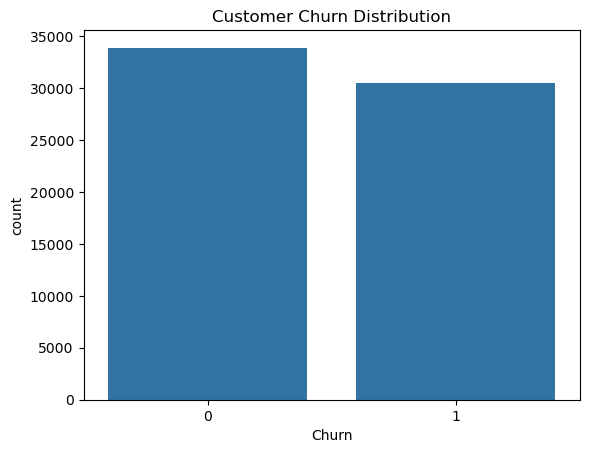

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Churn', data=df)
plt.title("Customer Churn Distribution")
plt.show()


In [8]:
churn_rate = df['Churn'].value_counts(normalize=True) * 100
print(churn_rate)


Churn
0    52.631497
1    47.368503
Name: proportion, dtype: float64


### Customer Behavior Analysis

We analyze how different behavioral factors influence churn, including:

- Tenure
- Support Calls
- Payment Delay
- Subscription Type


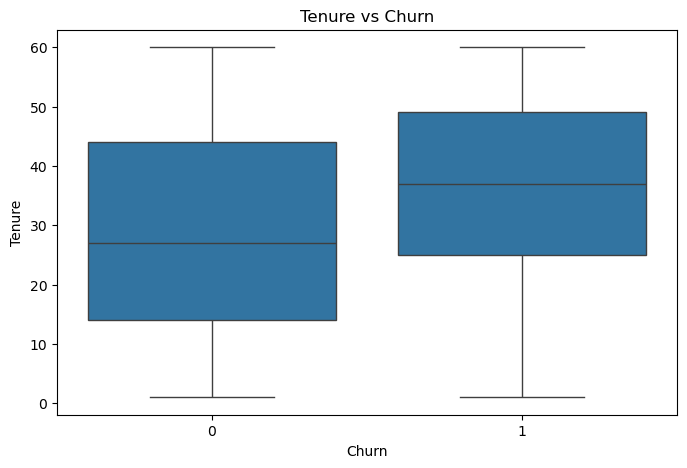

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='Tenure', data=df)
plt.title("Tenure vs Churn")
plt.show()


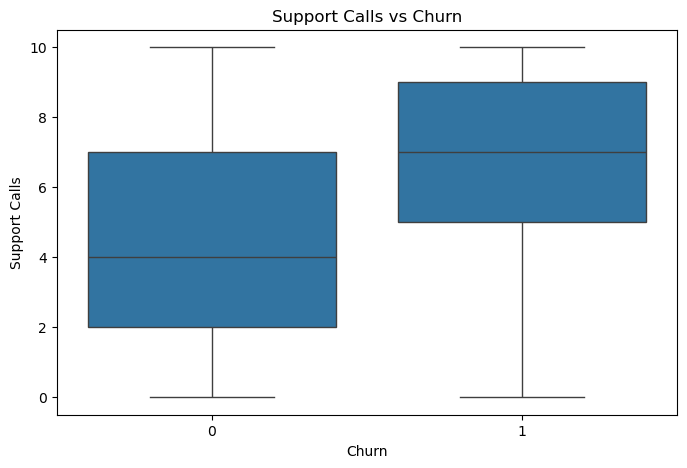

In [10]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='Support Calls', data=df)
plt.title("Support Calls vs Churn")
plt.show()


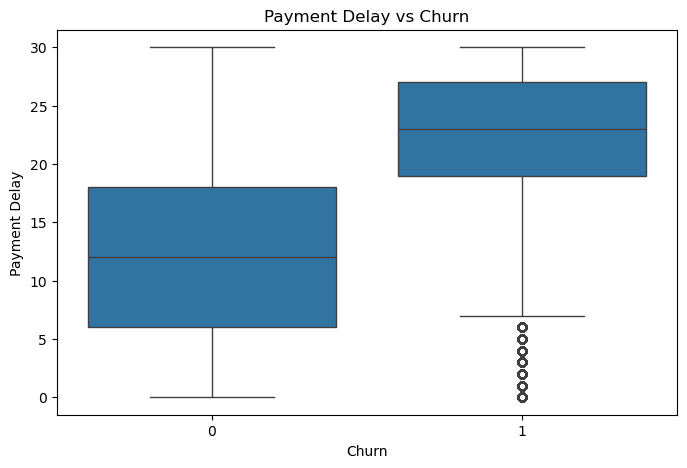

In [11]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='Payment Delay', data=df)
plt.title("Payment Delay vs Churn")
plt.show()


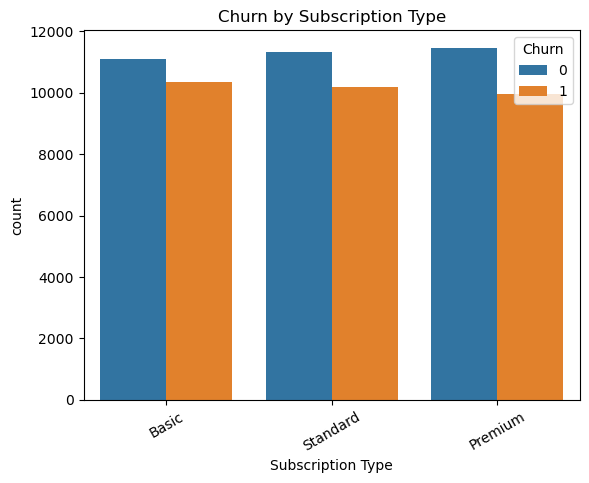

In [12]:
sns.countplot(x='Subscription Type', hue='Churn', data=df)
plt.title("Churn by Subscription Type")
plt.xticks(rotation=30)
plt.show()


## Feature Engineering

Categorical variables are converted into numerical features using one-hot encoding so that machine learning models can process them.


In [13]:
df_ml = df.copy()

df_ml = pd.get_dummies(df_ml, columns=["Gender","Subscription Type"], drop_first=True)

df_ml.head()


,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Contract Length,Total Spend,Last Interaction,Churn,Gender_Male,Subscription Type_Premium,Subscription Type_Standard
0,1,22,25,14,4,27,Monthly,598,9,1,False,False,False
1,2,41,28,28,7,13,Monthly,584,20,0,False,False,True
2,3,47,27,10,2,29,Annual,757,21,0,True,True,False
3,4,35,9,12,5,17,Quarterly,232,18,0,True,True,False
4,5,53,58,24,9,2,Annual,533,18,0,False,False,True


In [14]:
df_ml.columns


Index(['CustomerID', 'Age', 'Tenure', 'Usage Frequency', 'Support Calls',
       'Payment Delay', 'Contract Length', 'Total Spend', 'Last Interaction',
       'Churn', 'Gender_Male', 'Subscription Type_Premium',
       'Subscription Type_Standard'],
      dtype='object')

## Preparing Data for Machine Learning

The dataset is split into:

- Feature variables (X)
- Target variable (y)

The data is then divided into training and testing sets.


In [15]:
df_ml = df_ml.drop("CustomerID", axis=1)


In [16]:

from sklearn.preprocessing import StandardScaler


In [17]:
df_ml = pd.get_dummies(df_ml, columns=["Contract Length"], drop_first=True)


In [18]:
df_ml.columns


Index(['Age', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay',
       'Total Spend', 'Last Interaction', 'Churn', 'Gender_Male',
       'Subscription Type_Premium', 'Subscription Type_Standard',
       'Contract Length_Monthly', 'Contract Length_Quarterly'],
      dtype='object')

In [19]:
X = df_ml.drop("Churn", axis=1)
y = df_ml["Churn"]


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Logistic Regression Model

Logistic Regression is used as the baseline classification model to predict whether a customer will churn.


In [22]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=2000)

model.fit(X_train_scaled, y_train)



LogisticRegression(max_iter=2000)

In [23]:
y_pred = model.predict(X_test_scaled)


In [24]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.831611650485437
              precision    recall  f1-score   support

           0       0.85      0.83      0.84      6793
           1       0.82      0.83      0.82      6082

    accuracy                           0.83     12875
   macro avg       0.83      0.83      0.83     12875
weighted avg       0.83      0.83      0.83     12875



## Random Forest Model

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy.


In [25]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)


RandomForestClassifier(n_estimators=200, random_state=42)

In [26]:
rf_pred = rf_model.predict(X_test)


In [27]:
from sklearn.metrics import accuracy_score, classification_report

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))


Random Forest Accuracy: 0.998757281553398
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6793
           1       1.00      1.00      1.00      6082

    accuracy                           1.00     12875
   macro avg       1.00      1.00      1.00     12875
weighted avg       1.00      1.00      1.00     12875



### Model Validation

The Random Forest model initially achieved extremely high accuracy due to the strong influence of the **Payment Delay** feature.

To avoid potential data leakage, the model was retrained after removing this feature.


In [28]:
X_no_delay = X.drop("Payment Delay", axis=1)

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_no_delay, y, test_size=0.2, random_state=42
)

rf_model2 = RandomForestClassifier(n_estimators=200, random_state=42)

rf_model2.fit(X_train2, y_train2)

rf_pred2 = rf_model2.predict(X_test2)

print("Accuracy:", accuracy_score(y_test2, rf_pred2))
print(classification_report(y_test2, rf_pred2))


Accuracy: 0.7788737864077669
              precision    recall  f1-score   support

           0       0.89      0.66      0.76      6793
           1       0.71      0.91      0.80      6082

    accuracy                           0.78     12875
   macro avg       0.80      0.79      0.78     12875
weighted avg       0.80      0.78      0.78     12875



## Feature Importance Analysis

Feature importance helps identify the most influential factors affecting customer churn.


In [29]:
import pandas as pd

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance


Payment Delay                 0.436403
Support Calls                 0.159524
Tenure                        0.109014
Usage Frequency               0.084394
Gender_Male                   0.077019
Total Spend                   0.047646
Age                           0.040181
Contract Length_Monthly       0.026321
Last Interaction              0.009414
Contract Length_Quarterly     0.006479
Subscription Type_Premium     0.001820
Subscription Type_Standard    0.001784
dtype: float64

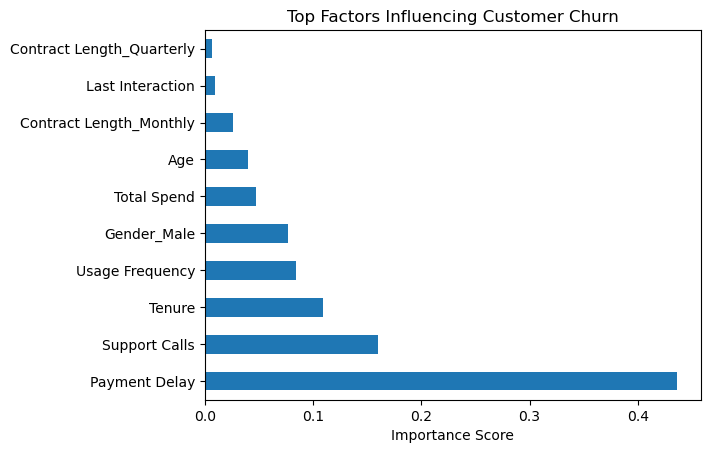

In [30]:
import matplotlib.pyplot as plt

feature_importance.head(10).plot(kind="barh")

plt.title("Top Factors Influencing Customer Churn")
plt.xlabel("Importance Score")

plt.show()


## Confusion Matrix

The confusion matrix evaluates the performance of the classification model by comparing predicted and actual churn values.


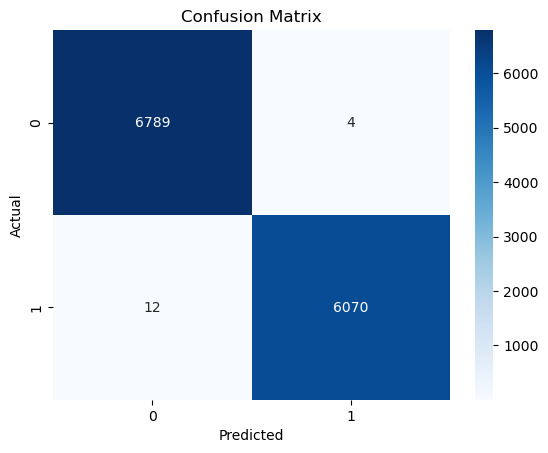

In [31]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


## Churn Probability Prediction

Instead of only predicting churn (0 or 1), the model calculates the probability that each customer will churn.


In [32]:
churn_prob = rf_model.predict_proba(X_test)[:,1]

df_results = X_test.copy()
df_results["Actual_Churn"] = y_test
df_results["Churn_Probability"] = churn_prob

df_results.head()


,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Gender_Male,Subscription Type_Premium,Subscription Type_Standard,Contract Length_Monthly,Contract Length_Quarterly,Actual_Churn,Churn_Probability
15476,55,20,24,4,6,635,25,True,False,True,True,False,0,0.010
34666,28,27,30,4,5,631,10,True,True,False,False,True,0,0.000
50474,65,60,17,7,16,314,1,False,True,False,False,True,1,0.980
7984,53,47,16,8,7,527,13,True,True,False,False,False,0,0.005
20227,32,56,5,7,15,236,25,True,True,False,False,False,0,0.070


## Customer Risk Segmentation

Customers are categorized into risk groups based on churn probability:

- Low Risk
- Medium Risk
- High Risk


In [33]:
df_results["Risk_Level"] = pd.cut(
    df_results["Churn_Probability"],
    bins=[0,0.3,0.6,1],
    labels=["Low Risk","Medium Risk","High Risk"]
)

df_results["Risk_Level"].value_counts()


Risk_Level
High Risk      6044
Low Risk       4904
Medium Risk      90
Name: count, dtype: int64

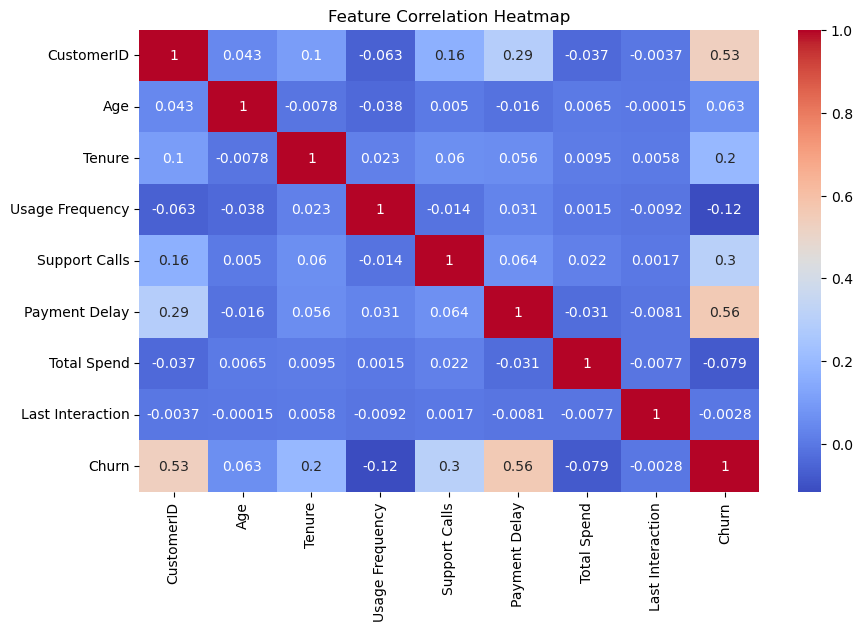

In [34]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", annot=True)
plt.title("Feature Correlation Heatmap")
plt.show()


## Conclusion

This project demonstrates how machine learning and data analysis can identify customer churn patterns and support data-driven retention strategies.

Key churn drivers include:

- Payment Delay
- Support Calls
- Tenure
- Usage Frequency
